In [37]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import hist
import mplhep as hep

In [38]:
def get_ratio_unc(num, denom):
    val_num = num.values()
    val_denom = denom.values()
    var_num = num.variances()
    var_denom = denom.variances()
    ratio = np.divide(val_num, val_denom, where=val_denom!=0, out=np.ones_like(val_denom))

    rel_var = np.divide(var_num, val_num**2, where=val_num!=0) + np.divide(var_denom, val_denom**2, where=val_denom!=0)
    ratio_var = (ratio**2)*rel_var
    return ratio, ratio_var


In [41]:
ttbar_jets = ak.from_parquet('/users/lhay/NegativeWeights/ttbar_NLO_100k_alljets.parquet')
radii = [5, 7, 10, 12, 15, 17, 18, 20, 25, 30]
rw_arrays = {}
for R in radii:
    rw_arrays[R] = np.load(f"/users/lhay/cres-distance/reweighted_files/ttbar_hp_100k/100k_hp_emd_reweight_{R}gev_bigR.npy")
weights_orig = np.load("/users/lhay/NegativeWeights/ttbar_weight_100k.npy")

Reweight fraction for R =  5 is  0.0
Reweight fraction for R =  7 is  0.06
Reweight fraction for R =  10 is  0.74
Reweight fraction for R =  12 is  1.55
Reweight fraction for R =  15 is  7.37
Reweight fraction for R =  17 is  16.57
Reweight fraction for R =  18 is  21.22
Reweight fraction for R =  20 is  37.33
Reweight fraction for R =  25 is  70.54
Reweight fraction for R =  30 is  87.26
x value where y = 100: 30.800229341521792
x value where y = 25: 18.50665675217467


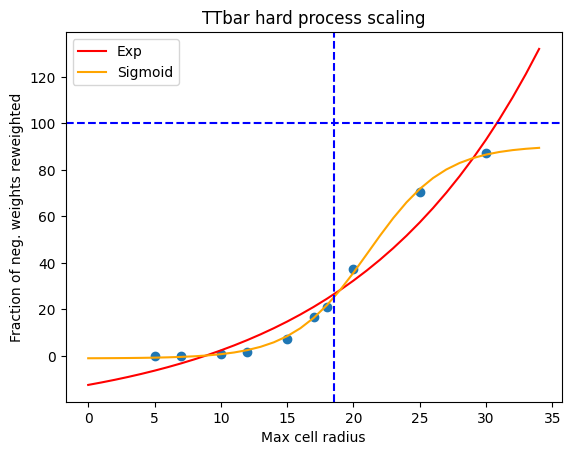

In [62]:
fracs = []
for R, weights in rw_arrays.items():
    frac = round((1-ak.sum(weights<0)/ak.sum(weights_orig<0))*100, 2)
    fracs.append(frac)
    print("Reweight fraction for R = ", R, "is ", frac)
plt.scatter(radii, fracs)
plt.xlabel("Max cell radius")
plt.ylabel("Fraction of neg. weights reweighted")
from scipy.optimize import curve_fit

def func(x, a, b, c):
    return a * np.exp(b * x) + c
def sigmoid(x ,L, x0, k, s):
    y = L / (1 + np.exp(-k*(x-x0))) + s
    return (y)
popt, pcov = curve_fit(func, np.array(radii), fracs)
x = np.arange(0, np.max(radii)+5)
a, b, c = popt
###initial guess
p0 = [max(fracs), np.median(np.array(radii)),1,min(fracs)]
popt_sig, pcov_sig = curve_fit(sigmoid, np.array(radii), fracs, p0)
L, x0, k, s = popt_sig

if (100 - c) / a > 0:
    x_100 = (1.0 / b) * np.log((100 - c) / a)
    print("x value where y = 100:", x_100)
else:
    print("No real solution for y = 100 with exp fit.")
des_frac = 25
if (L/(des_frac-s))-1 > 0:
    x_100 = x0-((1/k)*np.log((L/(des_frac-s))-1))
    print(f"x value where y = {des_frac}: {x_100}")
else:
    print("No real solution for y = 100 with sigmoid fit.")

plt.plot(x, func(x, *popt), 'r-', label="Exp")
plt.plot(x, sigmoid(x, *popt_sig), color='orange', linestyle='-', label="Sigmoid")
plt.title("TTbar hard process scaling")
plt.axvline(x=x_100, color='b', linestyle='--')
plt.axhline(y=100, color='b', linestyle='--')
plt.legend()
plt.show()

In [60]:
# def plot_obs(obs, orig_weights, new_weights, obs_str, nbins, xmin, xmax):

TypeError: unhashable type: 'slice'

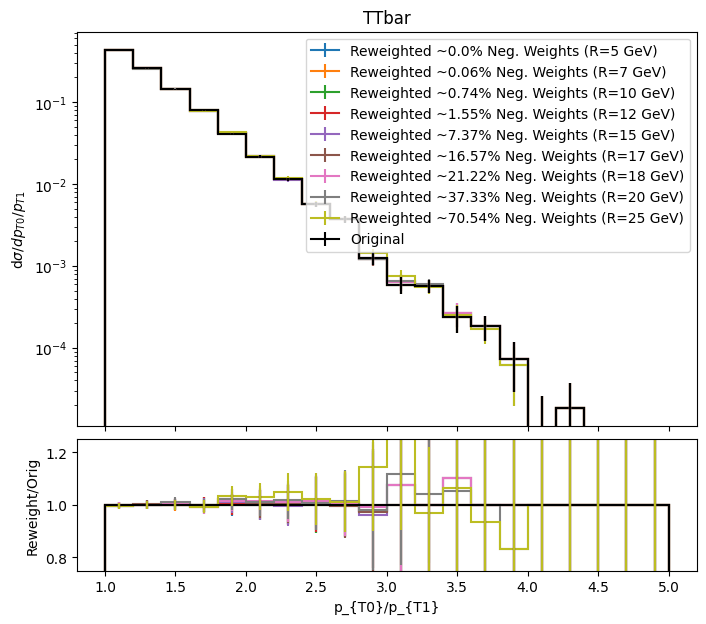

In [32]:
### plot njets
quantity = 'p_{T0}/p_{T1}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin = 1
xmax=5
sel = (ak.num(ttbar_jets.pt, axis=1)>1)
sel_jets = ttbar_jets[sel]
obs = sel_jets.pt[:,-1]/sel_jets.pt[:,-2]
def plot_obs(quantity, numbins, xmin, xmax, obs, weights_orig, rw_arrays, sel=None):
    if sel is None:
        sel  =np.ones_like(weights_orig, dtype=bool)
    sel_weights = weights_orig[sel]
    cmap  = cm.tab10.colors 
    fig, (ax, rax) = plt.subplots(nrows=2,
                            ncols=1,
                            figsize=(8,7),
                            gridspec_kw={"height_ratios": (3, 1)},
                            sharex=True)

    
    h_orig = hist.Hist(
            hist.axis.Regular(numbins,xmin, xmax,name="data",label="TTbar orig",),
            storage=hist.storage.Weight(), 
        )
    h_orig.fill(obs, weight = sel_weights)
    h_orig = h_orig/h_orig.sum(flow=False).value
    for i, R in enumerate(rw_arrays.keys()):
        weights = rw_arrays[R][sel]
        h = hist.Hist(
            hist.axis.Regular(numbins,xmin, xmax,name="data",label="TTbar reweighted",),
            storage=hist.storage.Weight(), 
        )
        h.fill(obs, weight = weights)
        #### Normalize hists
        h = h/h.sum(flow=False).value
        bin_centers = h.axes[0].centers
        bin_edges = h.axes[0].edges
        ratio, ratio_unc = get_ratio_unc(h, h_orig)
        hep.histplot(ratio, bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc), color=cmap[i])
        hep.histplot(h, ax=ax, label = f"{fracs[i]}% RW (R={R} GeV)", color=cmap[i])
    hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, color='black')
    hep.histplot(h_orig, ax=ax, label = "Original", color='black')
    rax.set_xlabel(quantity)
    rax.set_ylabel("Reweight/Orig")
    ax.set_title("TTbar")
    ax.set_ylabel(rf"d$\sigma/d{quantity}$")
    ax.set_xlabel(None)
    rax.set_ylim(0.75, 1.25)
    ax.set_yscale('log')
    
    ax.legend()
    plt.subplots_adjust(hspace=0.05)
    plt.show()
plot_obs(quantity, numbins, xmin, xmax, obs, weights_orig, rw_arrays, sel=sel)

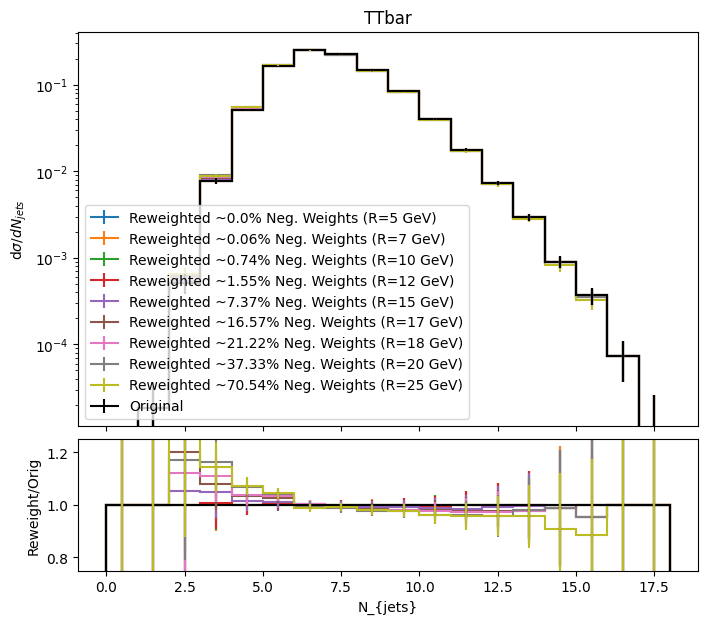

In [36]:
### plot njets
quantity = r'N_{jets}' #string for labels and stuff is the observable
numbins = 18 #number of bins
xmin=0
xmax=18
import matplotlib.cm as cm
cmap  = cm.tab10.colors 
plot_obs(quantity, numbins, xmin, xmax, njets, weights_orig, rw_arrays)

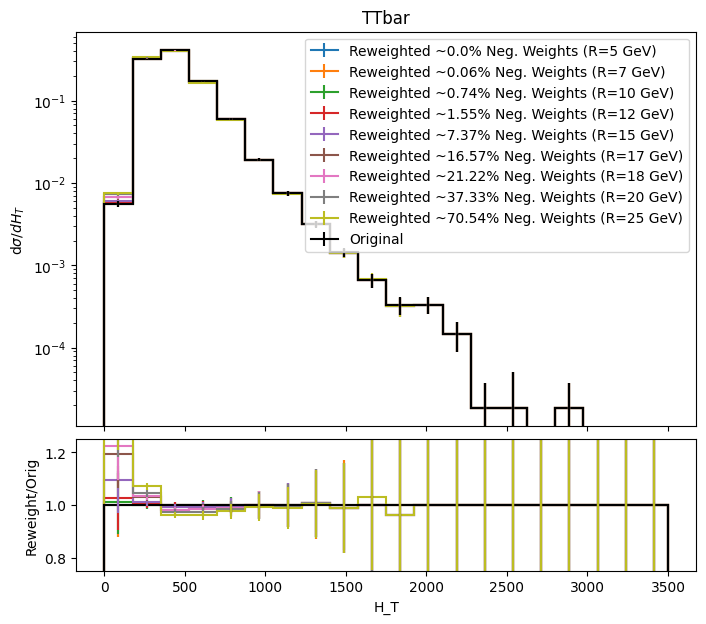

In [34]:
### plot njets
quantity = 'H_T' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=0
xmax=3500
ht = ak.sum(ttbar_jets.pt, axis=-1)
plot_obs(quantity, numbins, xmin, xmax, ht, weights_orig, rw_arrays)

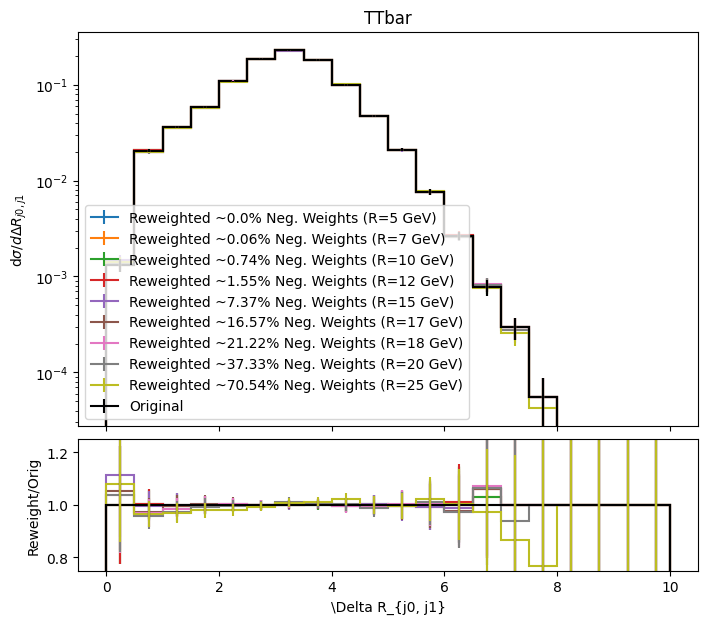

In [35]:
quantity = "\Delta R_{j0, j1}"
xmin = 0
xmax = 10
obs= np.sqrt((sel_jets.eta[:,-1] - sel_jets.eta[:,-2])**2 + (sel_jets.phi[:,-1] - sel_jets.phi[:,-2])**2)
plot_obs(quantity, numbins, xmin, xmax, obs, weights_orig, rw_arrays, sel)